In [1]:
import pandas as pd
import numpy as np
import os
import pandas as pd
import wrds
from pandas.tseries.offsets import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV

import matplotlib.pyplot as plt

from sklearn.pipeline      import Pipeline
from sklearn.impute        import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

data_folder = 'data/'

### Import Data

### Load Data

In [2]:
crsp_stock_df = pd.read_pickle(data_folder + 'stocks.pkl')
funda_raw = pd.read_csv(data_folder+'funda.csv')
rf_raw = pd.read_pickle(data_folder+'risk_free.pkl')
# print(funda_raw)

### Data Cleaning

#### stock data cleaning

In [3]:
# stock data cleaning 
def CRSP_stock_data_cleaning(CRSP_Stocks):
    CRSP_Stocks = CRSP_Stocks.copy()
    CRSP_Stocks = CRSP_Stocks[
         (CRSP_Stocks['shrcd'].isin([10, 11])) & 
         (CRSP_Stocks['exchcd'].isin([1, 2, 3]))
      ]
    
    # dropna
    CRSP_Stocks = CRSP_Stocks.dropna(subset = ['prc', 'shrout'])
    # prc = -99.0 is defined as missing in CRSP
    CRSP_Stocks['prc'] = CRSP_Stocks['prc'].replace(-99.0, np.nan)

    # Handle returns with delisting (If return and delist return are both NA, we can consider that is missing data for some reason)
    idx = CRSP_Stocks[(CRSP_Stocks['ret'].isna() & CRSP_Stocks['dlret'].isna())].index
    CRSP_Stocks['dlret'] = CRSP_Stocks['dlret'].fillna(0)
    CRSP_Stocks['ret'] = CRSP_Stocks['ret'].fillna(0)
    CRSP_Stocks['ret'] = (1 + CRSP_Stocks['ret']) * (1 + CRSP_Stocks['dlret']) - 1
    # Substituing missing returns with zero (no trade assumption)
    CRSP_Stocks.loc[CRSP_Stocks['ret'].isna(),'ret'] = 0
      # This line only give NaN value to the row with both NaNs
    CRSP_Stocks.loc[idx, ['ret']] = np.nan

    # lag Market Equity
    CRSP_Stocks['me'] = CRSP_Stocks['prc'].abs() * CRSP_Stocks['shrout'] * 1000
   
    CRSP_Stocks = CRSP_Stocks.sort_values(by=['permno','date']).reset_index().drop('index',axis=1).copy()
    CRSP_Stocks['date_number'] = CRSP_Stocks['date'].dt.year * 12 + CRSP_Stocks['date'].dt.month
    CRSP_Stocks['IsValidLag'] = CRSP_Stocks['date_number'].diff(1) == 1
    CRSP_Stocks.loc[CRSP_Stocks[CRSP_Stocks['permno'].diff(1) != 0].index,['IsValidLag']] = False
    CRSP_Stocks['lag_me']= CRSP_Stocks[["permno","me"]].groupby("permno").shift(1)
    CRSP_Stocks = CRSP_Stocks.drop(["IsValidLag","date_number"], axis=1)
    
    # 12 months rolling return (t-14 to t-2 and skip t-1)
    CRSP_Stocks['rolling_ret_12m'] = CRSP_Stocks.groupby('permno')['ret'] \
                           .transform(lambda x: x.shift(2)
                           .rolling(12, min_periods=12)
                           .sum())

    # next return as Y
    CRSP_Stocks['next_return'] = CRSP_Stocks.groupby('permno')['ret'].transform(lambda x: x.shift(-1))

    mask = (
       CRSP_Stocks['rolling_ret_12m'].notna() &
       CRSP_Stocks['ret'].notna() &
       CRSP_Stocks['next_return'].notna()
    )

    CRSP_Stocks = CRSP_Stocks.loc[mask].copy()
    
    CRSP_Stocks['year'] = CRSP_Stocks['date'].dt.year
    CRSP_Stocks['month'] = CRSP_Stocks['date'].dt.month

    # industry code for 2 digits
    CRSP_Stocks['sic2'] = CRSP_Stocks['siccd'].astype(str).str[:2]

    CRSP_Stocks = CRSP_Stocks[(CRSP_Stocks['year'] >= 1927) & (CRSP_Stocks['year'] <= 2024)]

    # change lagged equity to millions
    CRSP_Stocks['lag_me'] = CRSP_Stocks['lag_me'] / 1e6

    out_df = CRSP_Stocks[['year','month','permno', 'next_return', 'lag_me', 'ret', 'rolling_ret_12m', 'sic2']]
    out_df = out_df.sort_values(by=['year', 'month'], ascending=[True, True]).reset_index(drop=True)
    out_df = out_df.rename(columns={
                           'lag_me': 'lag_mkt_cap', # in millions
                           'ret': 'ret_1m',
                           'rolling_ret_3m': 'rolling_ret_3m',
                           'rolling_ret_6m': 'rolling_ret_6m',
                           'rolling_ret_12m': 'rolling_ret_12m',
                           'sic2': 'industry_code'
                           })

    return out_df

In [4]:
stock_df_cleaned = CRSP_stock_data_cleaning(crsp_stock_df)

rf_df = rf_raw.copy()
rf_df['year'] = rf_df['date'].dt.year
rf_df['month'] = rf_df['date'].dt.month
rf_df = rf_df.drop(columns='date')

stock_df_cleaned = pd.merge(stock_df_cleaned, rf_df, on=['year','month'], how='left')
print(stock_df_cleaned)

        year  month  permno  next_return    lag_mkt_cap    ret_1m  \
0       2011      2   10001     0.072404       84.45052  0.022727   
1       2011      2   10002    -0.068182       49.03642  -0.05036   
2       2011      2   10025     0.058405      170.07198  0.014085   
3       2011      2   10026     0.073175      788.71037  0.035319   
4       2011      2   10028     0.223667       43.46628 -0.057059   
...      ...    ...     ...          ...            ...       ...   
578867  2024     11   93374     -0.10221      6607.7066  0.093531   
578868  2024     11   93397    -0.117446      462.36612  0.084243   
578869  2024     11   93426     0.021768      283.90472  -0.01034   
578870  2024     11   93434     0.133333         5.2532  2.065217   
578871  2024     11   93436     0.170008  802033.523101  0.381469   

        rolling_ret_12m industry_code      rf30  
0              0.102148            49  0.000122  
1              0.122187            60  0.000122  
2             -0.2962

### Clean Fundamental Data

In [5]:
funda_df = funda_raw.sort_values(['GVKEY', 'datadate']).reset_index(drop=True)

funda_df['bm'] = ((funda_df['ceq'] + funda_df['txdb'] - funda_df['pstk']) 
                  / (funda_df['prcc_f'] * funda_df['csho']))

funda_df['ep'] = funda_df['oibdp'] / funda_df['prcc_f']
funda_df['div_yield'] = (funda_df['dvc'] / funda_df['csho']) / funda_df['prcc_f']
# sales to price
funda_df['sp'] = funda_df['sale'] / funda_df['prcc_f']

# leverage and cashflow
funda_df['operprof'] = funda_df['oibdp'] / funda_df['at']
# gross profit
funda_df['grossprof'] = (funda_df['sale'] - funda_df['cogs']) / funda_df['at']

funda_df['roe'] = funda_df['ni'] / (funda_df['ceq'] + funda_df['txdb'] - funda_df['pstk'])
# accruals
funda_df['acc'] = (funda_df['ni'] - funda_df['oancf']) / funda_df['at']

# 2. 先生成所有需要的滞后变量（lag）
grp = funda_df.groupby('GVKEY')
funda_df['lag_at']      = grp['at'].shift(1)
funda_df['lag_capx']    = grp['capx'].shift(1)
funda_df['lag_invt']    = grp['invt'].shift(1)
funda_df['lag_csho']    = grp['csho'].shift(1)
# 滞后市值 * 股本，用于 net issuance
funda_df['lag_prcc_f']  = grp['prcc_f'].shift(1)
funda_df['lag_che']     = grp['che'].shift(1)

funda_df['cashpr'] = (funda_df['che'] - funda_df['lag_che']) / funda_df['lag_at']

# 3. 计算“投资/成长”因子
funda_df['agr']         = (funda_df['at'] - funda_df['lag_at']) / funda_df['lag_at']
funda_df['invest']      = funda_df['capx'] / funda_df['lag_at']
funda_df['pchcapx_ia']  = (funda_df['capx'] - funda_df['lag_capx']) / funda_df['lag_at']
funda_df['chinv']       = (funda_df['invt'] - funda_df['lag_invt']) / funda_df['lag_at']
funda_df['chcsho']      = (funda_df['csho'] - funda_df['lag_csho']) / funda_df['lag_csho']
funda_df['nincr']       = ((funda_df['prcc_f'] * funda_df['csho'])
                          - (funda_df['lag_prcc_f'] * funda_df['lag_csho'])) \
                         / (funda_df['lag_prcc_f'] * funda_df['lag_csho'])

# 4. 计算“杠杆 & 现金流”因子
funda_df['lev']         = (funda_df['dltt'] + funda_df['dlc']) / funda_df['at']
funda_df['cashdebt']    = funda_df['che'] / (funda_df['dltt'] + funda_df['dlc'])
funda_df['tang']        = (funda_df['ceq'] - funda_df['intan']) / funda_df['at']
funda_df['cfp']         = funda_df['oancf'] / (funda_df['prcc_f'] * funda_df['csho'])
funda_df['cashpr']      = (funda_df['che'] - funda_df['lag_che']) / funda_df['lag_at']

# （可选）5. 丢弃因 lag 导致的前一行 NaN
funda_df = funda_df.dropna(subset=[
    'agr','invest','pchcapx_ia','chinv','chcsho','nincr',
    'lev','cashdebt','tang','cfp','cashpr'
])

funda_df = funda_df.drop(columns=['GVKEY', 'LPERMCO', 'fyear', 'fyr', 'at', 'capx', 'ceq', \
                                  'che', 'cogs', 'csho', 'dlc', 'dltt', \
                                    'dvc', 'intan', 'invt', 'ni', 'oancf', \
                                        'oibdp', 'optvol', 'pstk', 'sale', \
                                            'txdb', 'prcc_f', 'lag_at', 'lag_capx', \
                                                'lag_capx', 'lag_invt', 'lag_csho', 'lag_prcc_f'], axis=1)

print(funda_df)

        LPERMNO    datadate        bm          ep  div_yield           sp  \
1         54594  1995-05-31  0.935802    2.279738   0.031429    29.599674   
2         54594  1996-05-31  0.664815    1.923480   0.021686    22.824408   
3         54594  1997-05-31  0.534833    1.779904   0.014134    19.010590   
4         54594  1998-05-31  0.461071    2.988142   0.012449    29.583849   
5         54594  1999-05-31  0.685877    4.781975   0.017336    46.482835   
...         ...         ...       ...         ...        ...          ...   
197038    16161  2023-12-31  1.169949   -1.890928   0.000000     0.000000   
197039    16161  2024-12-31  1.580946  -14.489012   0.000000     0.000000   
197041    23773  2024-12-31  1.782831   30.091950   0.173505    42.578239   
197043    23209  2023-12-31  0.673534  434.454070   0.013006  1749.269502   
197044    23209  2024-12-31  0.565847  362.447484   0.016524  1474.066352   

        operprof  grossprof       roe       acc  ...       agr    invest  \

In [6]:
# lag 6 month
funda_df['datadate'] = pd.to_datetime(funda_df['datadate'], format='%Y-%m-%d') + MonthEnd(0)
funda_df['publish_date'] = funda_df['datadate'] + pd.DateOffset(months=6) + MonthEnd(0)
funda_df = funda_df.drop('datadate', axis=1)
funda_df.rename(
    columns={
        'LPERMNO':    'permno',
        'publish_date': 'date'
    },
    inplace=True
)
print(funda_df)

        permno        bm          ep  div_yield           sp  operprof  \
1        54594  0.935802    2.279738   0.031429    29.599674  0.081646   
2        54594  0.664815    1.923480   0.021686    22.824408  0.097196   
3        54594  0.534833    1.779904   0.014134    19.010590  0.104189   
4        54594  0.461071    2.988142   0.012449    29.583849  0.117811   
5        54594  0.685877    4.781975   0.017336    46.482835  0.129975   
...        ...       ...         ...        ...          ...       ...   
197038   16161  1.169949   -1.890928   0.000000     0.000000 -0.762183   
197039   16161  1.580946  -14.489012   0.000000     0.000000 -0.600166   
197041   23773  1.782831   30.091950   0.173505    42.578239  0.106650   
197043   23209  0.673534  434.454070   0.013006  1749.269502  0.082425   
197044   23209  0.565847  362.447484   0.016524  1474.066352  0.080490   

        grossprof       roe       acc   lag_che  ...    invest  pchcapx_ia  \
1        0.207130  0.045935 -0.01

In [7]:
funda_df["year"] = funda_df['date'].dt.year
funda_df['month'] = funda_df['date'].dt.month
funda_df = funda_df.drop('date', axis=1)

merged = stock_df_cleaned.merge(funda_df, on=['year', 'month', 'permno'], how='left')

merged = merged.sort_values(['permno','year', 'month'])
factor_cols = ['bm', 'ep', 'div_yield', 'sp', 'operprof', 'grossprof', 'roe', 'acc', 'lag_che', 'cashpr', 'agr', 'invest', 'pchcapx_ia', 'chinv', 'chcsho', 'nincr', 'lev', 'cashdebt', 'tang', 'cfp']
merged[factor_cols] = merged.groupby('permno')[factor_cols].ffill()
merged = merged.dropna(subset=factor_cols)
print(merged)

        year  month  permno  next_return    lag_mkt_cap    ret_1m  \
57746   2012      6   10001     0.009406       85.06708 -0.027325   
61278   2012      7   10001    -0.012315        82.3756  0.009406   
64798   2012      8   10001     0.000501        82.7834 -0.012315   
68311   2012      9   10001     0.012676       81.40686  0.000501   
71815   2012     10   10001    -0.045504       81.08058  0.012676   
...      ...    ...     ...          ...            ...       ...   
564253  2024      7   93436    -0.077391    632155.3632  0.172781   
567933  2024      8   93436     0.221942  741380.136746 -0.077391   
571598  2024      9   93436    -0.045025    684004.3704  0.221942   
575246  2024     10   93436     0.381469      839047.41 -0.045025   
578871  2024     11   93436     0.170008  802033.523101  0.381469   

        rolling_ret_12m industry_code      rf30        bm  ...       agr  \
57746          0.070220            49  0.000022  0.834204  ...  0.135651   
61278         -0.04

#### industry code dummies

In [8]:
df = merged.copy()
df['industry_code'] = pd.to_numeric(df['industry_code'], errors='coerce')
ind_dummies = pd.get_dummies(
    df['industry_code'],
    prefix='ind',
    drop_first=False,
    dummy_na=False,
    dtype=int
)

df = pd.concat([df, ind_dummies], axis=1)
df = df.drop(columns=['industry_code'])
print(df)

        year  month  permno  next_return    lag_mkt_cap    ret_1m  \
57746   2012      6   10001     0.009406       85.06708 -0.027325   
61278   2012      7   10001    -0.012315        82.3756  0.009406   
64798   2012      8   10001     0.000501        82.7834 -0.012315   
68311   2012      9   10001     0.012676       81.40686  0.000501   
71815   2012     10   10001    -0.045504       81.08058  0.012676   
...      ...    ...     ...          ...            ...       ...   
564253  2024      7   93436    -0.077391    632155.3632  0.172781   
567933  2024      8   93436     0.221942  741380.136746 -0.077391   
571598  2024      9   93436    -0.045025    684004.3704  0.221942   
575246  2024     10   93436     0.381469      839047.41 -0.045025   
578871  2024     11   93436     0.170008  802033.523101  0.381469   

        rolling_ret_12m      rf30        bm         ep  ...  ind_82  ind_83  \
57746          0.070220  0.000022  0.834204   1.300263  ...       0       0   
61278        

### Training & Test

In [9]:
# Since 2011 has less columns, drop it
df = df[df['year'] > 2011].copy()
df['date'] = pd.to_datetime(
    df[['year','month']].assign(day=1)   # 补上 day=1
) + MonthEnd(0)

df['excess_next_return'] = df['next_return'] - df['rf30']
df['excess_mom_1m'] = df['ret_1m'] - df['rf30']
df['excess_mom_12m'] = df['rolling_ret_12m'] - df['rf30']

df_clean = df.sort_values('date').reset_index(drop=True).copy()

print(df_clean)

        year  month  permno  next_return    lag_mkt_cap    ret_1m  \
0       2012      1   14656     0.012252     4379.17214  0.107244   
1       2012      1   78915     0.057297       249.5073  0.096621   
2       2012      1   78910    -0.073171        67.9341  0.051282   
3       2012      1   78908     0.058568        67.5598  0.230588   
4       2012      1   78903     0.040921      155.60867  0.056043   
...      ...    ...     ...          ...            ...       ...   
481977  2024     11   87725    -0.083786      524.62044  0.131257   
481978  2024     11   19813    -0.215736     583.800525 -0.275069   
481979  2024     11   19814    -0.285714       50.62972  0.021898   
481980  2024     11   61146    -0.104387     2140.39316  0.375487   
481981  2024     11   93436     0.170008  802033.523101  0.381469   

        rolling_ret_12m      rf30        bm         ep  ...  ind_89  ind_94  \
0              0.031211 -0.000002  0.912535  27.611015  ...       0       0   
1            

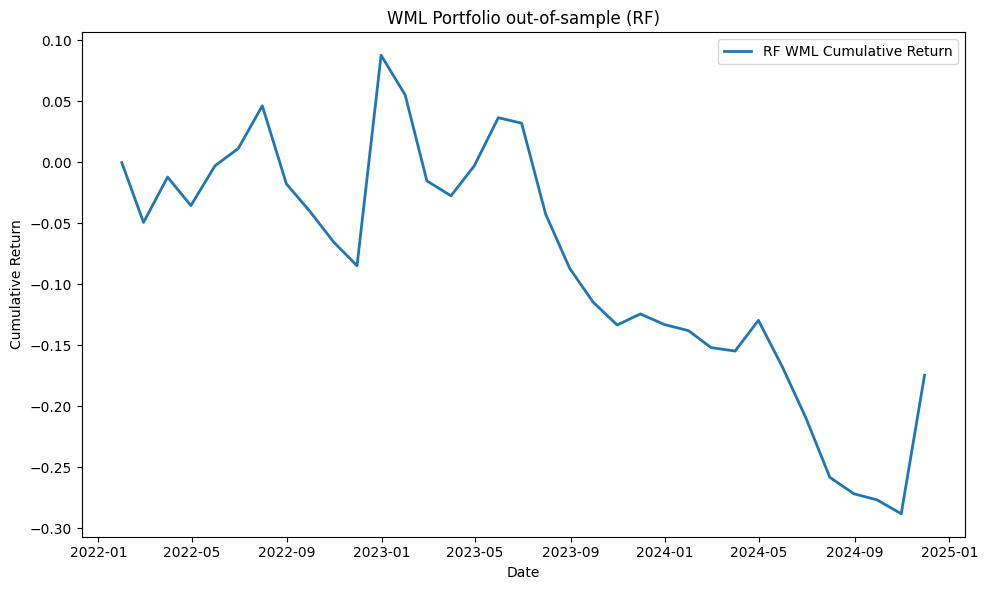

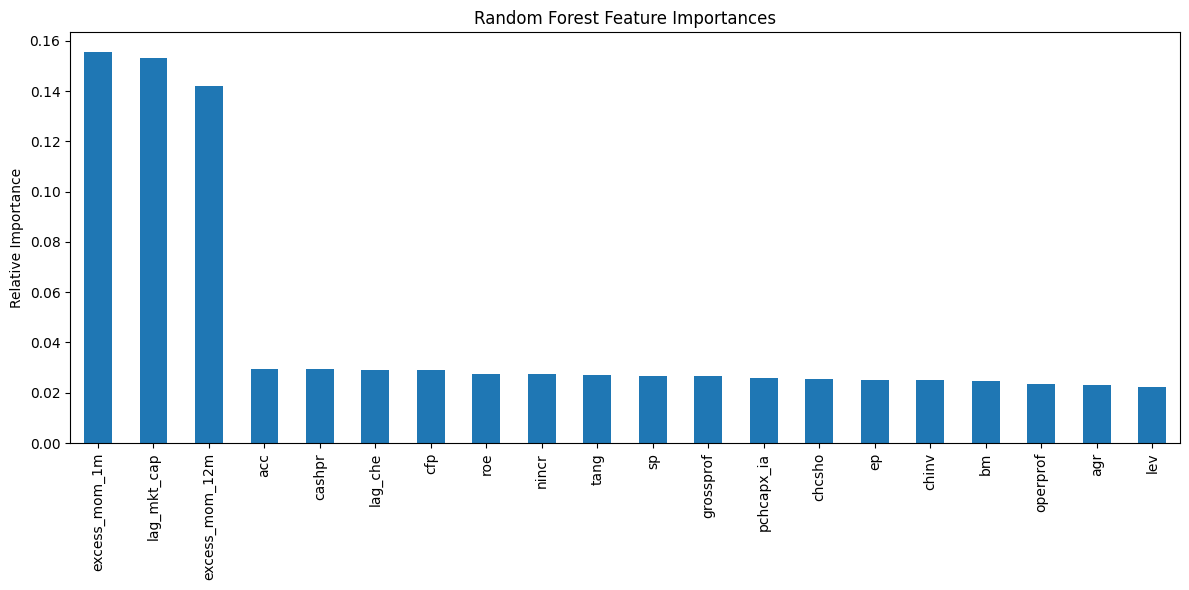

In [12]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# 1. (Optional) Combine train + val for more data
X_fit = pd.concat([X_train, X_val])
y_fit = pd.concat([y_train, y_val])

# 2. Instantiate and fit Random Forest with default parameters
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_fit, y_fit)

# 3. Predict on your test set
y_pred = rf.predict(X_test)

# 4. Merge predictions back into your cleaned DataFrame
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred

# 5. Build decile‐long (10) vs. decile‐short (1) WML portfolio
df_test['quantile'] = (
    df_test
      .groupby('date')['y_pred']
      .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)
winners = df_test[df_test['quantile'] == 10].groupby('date')['excess_next_return'].mean()
losers  = df_test[df_test['quantile'] ==  1].groupby('date')['excess_next_return'].mean()
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 6. Plot cumulative WML return
plt.figure(figsize=(10, 6))
plt.plot(cum_wml.index, cum_wml.values, label='RF WML Cumulative Return', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio out-of-sample (RF)')
plt.legend()
plt.tight_layout()
plt.show()

# 7. Plot feature importances (showing top 20)
importances = pd.Series(rf.feature_importances_, index=X_fit.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(20).plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.ylabel('Relative Importance')
plt.tight_layout()
plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
....................................[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    1.2s finished


🔍 Best alpha: 1.0
🔍 Best l1_ratio: 0.9


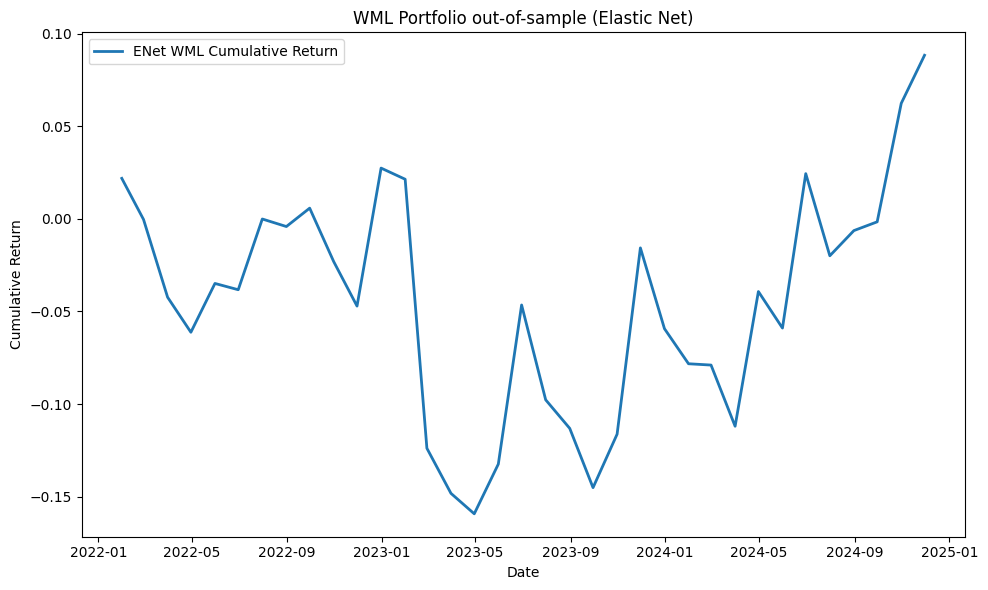

In [14]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import matplotlib.pyplot as plt

# 1. Combine train + val for tuning
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# 2. Set up time-series CV and ElasticNetCV
tscv = TimeSeriesSplit(n_splits=3)
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.9],      # mix of L1 vs. L2
    alphas=[0.001, 0.01, 0.1, 1],  # penalty strengths
    cv=tscv,
    max_iter=10000,
    n_jobs=-1,
    verbose=1
)

# 3. Fit and print best hyperparameters
enet_cv.fit(X_tune, y_tune)
print("🔍 Best alpha:", enet_cv.alpha_)
print("🔍 Best l1_ratio:", enet_cv.l1_ratio_)

# 4. Predict on test set
y_pred = enet_cv.predict(X_test)

# 5. Merge predictions into your cleaned DataFrame
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred

# 6. Construct decile‐long vs. decile‐short WML portfolio
df_test['quantile'] = (
    df_test
      .groupby('date')['y_pred']
      .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)
winners = df_test[df_test['quantile'] == 10].groupby('date')['excess_next_return'].mean()
losers  = df_test[df_test['quantile'] ==  1].groupby('date')['excess_next_return'].mean()
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 7. Plot cumulative WML return
plt.figure(figsize=(10, 6))
plt.plot(cum_wml.index, cum_wml.values, label='ENet WML Cumulative Return', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio out-of-sample (Elastic Net)')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# ——— 1. Regression metrics on test set —————————————————————————————————————
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")

# ——— 2. Portfolio metrics for your WML series ——————————————————————————————
# Assuming `wml` is a pd.Series of out-of-sample WML returns (monthly frequency)
ann_factor = 12  # use 12 for monthly data

mean_ret   = wml.mean()
vol        = wml.std()
sharpe     = mean_ret / vol * np.sqrt(ann_factor)
cagr       = (1 + wml).prod()**(ann_factor/len(wml)) - 1
max_dd     = ( (1 + wml).cumprod().cummax() - (1 + wml).cumprod() ).max()

metrics = pd.Series({
    'Annualized Return (CAGR)': cagr,
    'Annualized Volatility':    vol * np.sqrt(ann_factor),
    'Sharpe Ratio':             sharpe,
    'Max Drawdown':             max_dd
})
print("\nWML Portfolio Metrics:")
print(metrics.to_frame(name='Value'))

MSE:  0.059405
RMSE: 0.243731
MAE:  0.127732
R²:   -0.0022

WML Portfolio Metrics:
                             Value
Annualized Return (CAGR)  0.029443
Annualized Volatility     0.176939
Sharpe Ratio              0.250091
Max Drawdown              0.186673


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
..................................................................................................................................................................................................................................................................................................................................................................................................................................................................[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    1.8s finished


🔍 Best alpha: 0.008531678524172805
🔍 Best l1_ratio: 0.5


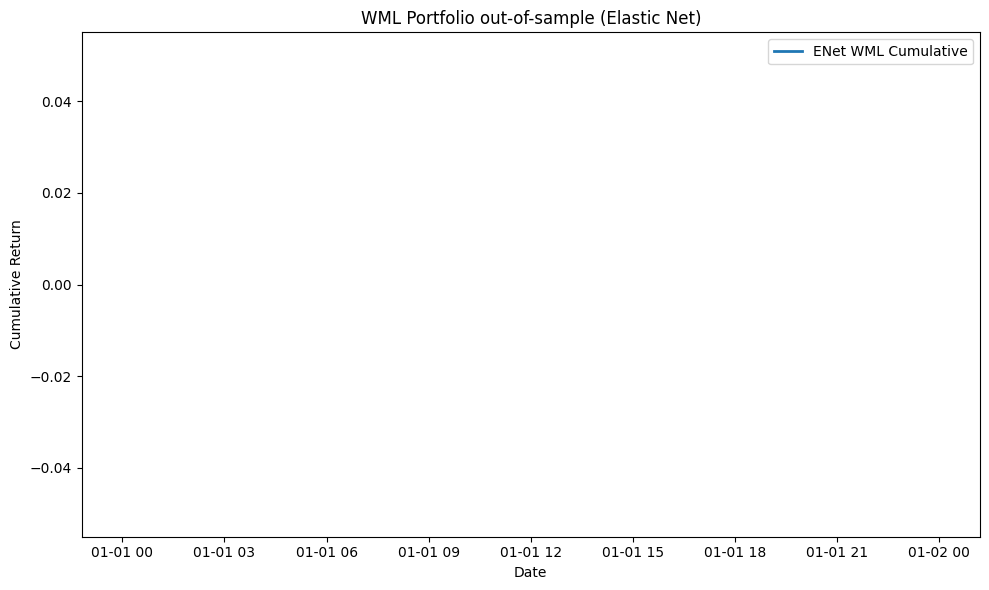

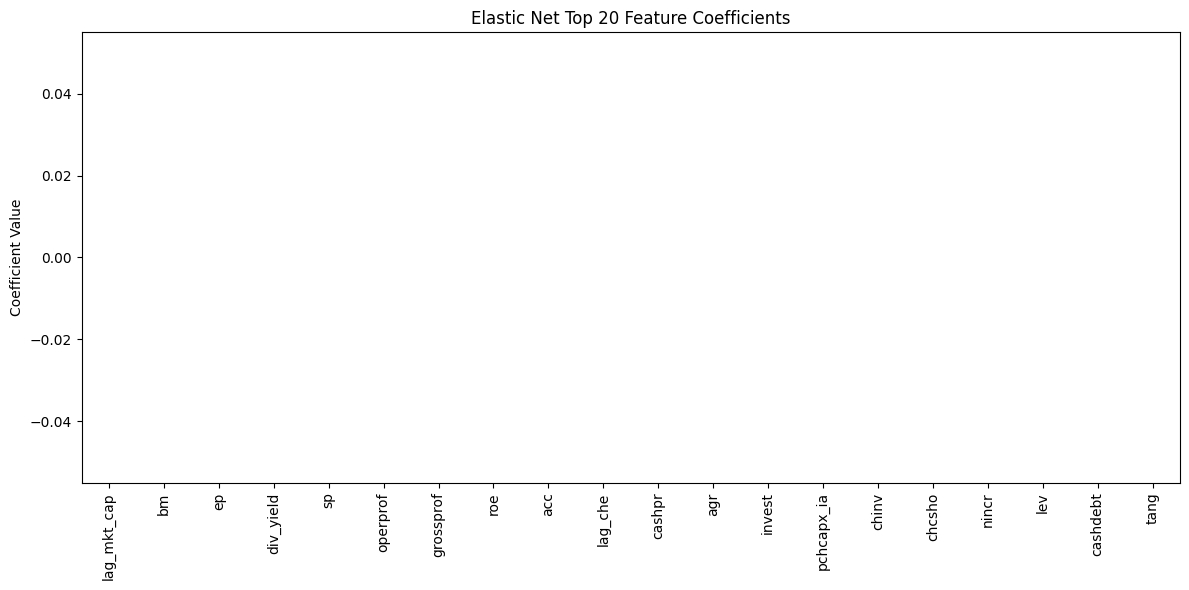

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit

# 1. Combine train + val for tuning
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# 2. Build Pipeline with imputation, scaling, ElasticNetCV
tscv = TimeSeriesSplit(n_splits=5)
pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
    ('enet',   ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],                # mix of L1 vs. L2
        alphas=np.logspace(-4, 0, 30),           # penalty strengths
        cv=tscv,
        max_iter=10000,
        n_jobs=-1,
        verbose=1,
        random_state=42
    ))
])

# 3. Fit pipeline
pipe.fit(X_tune, y_tune)
best_enet = pipe.named_steps['enet']
print("🔍 Best alpha:",    best_enet.alpha_)
print("🔍 Best l1_ratio:", best_enet.l1_ratio_)

# 4. Predict on test set
y_pred = pipe.predict(X_test)

# 5. Attach predictions back to your cleaned df
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred

# 6. Build decile‐long vs. decile‐short WML
df_test['quantile'] = (
    df_test
      .groupby('date')['y_pred']
      .transform(lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') + 1)
)
winners = df_test[df_test['quantile'] == 10].groupby('date')['excess_next_return'].mean()
losers  = df_test[df_test['quantile'] ==  1].groupby('date')['excess_next_return'].mean()
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 7. Plot cumulative WML return
plt.figure(figsize=(10,6))
plt.plot(cum_wml.index, cum_wml, label='ENet WML Cumulative', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio out-of-sample (Elastic Net)')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
df_test

,year,month,permno,next_return,lag_mkt_cap,ret_1m,rolling_ret_12m,rf30,bm,ep,...,ind_95,ind_96,ind_97,ind_99,date,excess_next_return,excess_mom_1m,excess_mom_12m,y_pred,quantile
367372,2022,1,90825,0.056511,790.73806,-0.014528,0.123664,0.000044,1.138397,22.461538,...,0,0,0,0,2022-01-31,0.056467,-0.014572,0.12362,0.012446,NaN
367373,2022,1,15623,-0.032179,5279.31296,0.026662,0.576475,0.000044,0.305044,6.384649,...,0,0,0,0,2022-01-31,-0.032223,0.026618,0.576431,0.012446,NaN
367374,2022,1,83155,0.010587,140.92645,0.003616,0.267344,0.000044,1.206693,0.927585,...,0,0,0,0,2022-01-31,0.010543,0.003572,0.2673,0.012446,NaN
367375,2022,1,76708,-0.293678,1471.0534,-0.004736,0.094550,0.000044,0.756567,7.030051,...,0,0,0,0,2022-01-31,-0.293722,-0.00478,0.094506,0.012446,NaN
367376,2022,1,18408,-0.153409,101.80444,-0.263598,-0.405368,0.000044,0.062524,-8.467143,...,0,0,0,1,2022-01-31,-0.153453,-0.263642,-0.405412,0.012446,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481977,2024,11,87725,-0.083786,524.62044,0.131257,0.106943,0.003955,0.616092,1.479267,...,0,0,0,0,2024-11-30,-0.087741,0.127302,0.102988,0.012446,NaN
481978,2024,11,19813,-0.215736,583.800525,-0.275069,-0.090832,0.003955,0.250154,-11.288687,...,0,0,0,1,2024-11-30,-0.219691,-0.279024,-0.094787,0.012446,NaN
481979,2024,11,19814,-0.285714,50.62972,0.021898,-2.310887,0.003955,0.097701,-10.406497,...,0,0,0,1,2024-11-30,-0.289669,0.017943,-2.314842,0.012446,NaN
481980,2024,11,61146,-0.104387,2140.39316,0.375487,0.393591,0.003955,0.273589,-0.960542,...,0,0,0,0,2024-11-30,-0.108342,0.371532,0.389636,0.012446,NaN


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
......................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

Best alpha:    0.26529484644318946
Best l1_ratio: 0.01
MSE: 0.059396, RMSE: 0.243714, R²: -0.0020


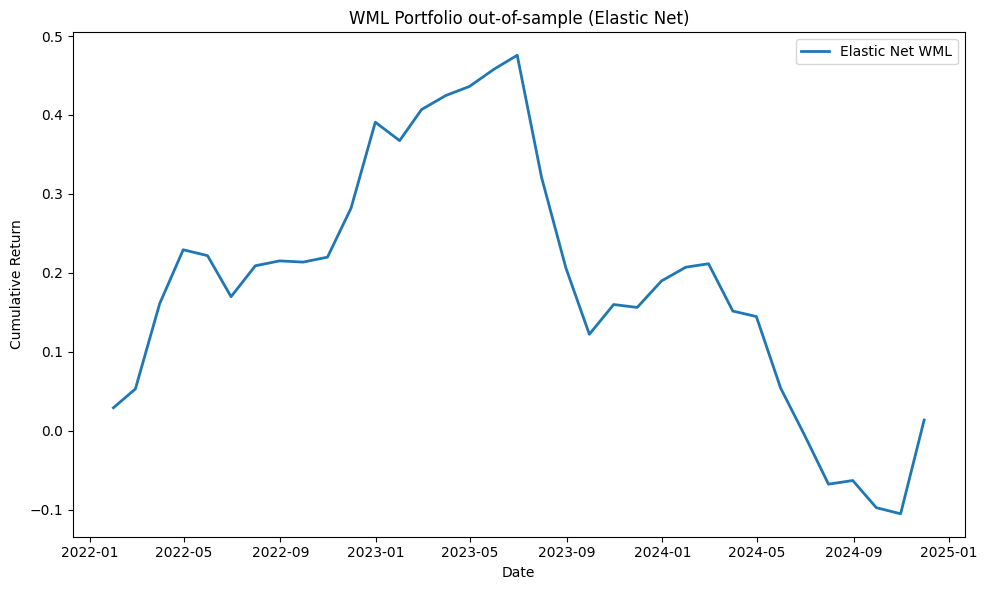

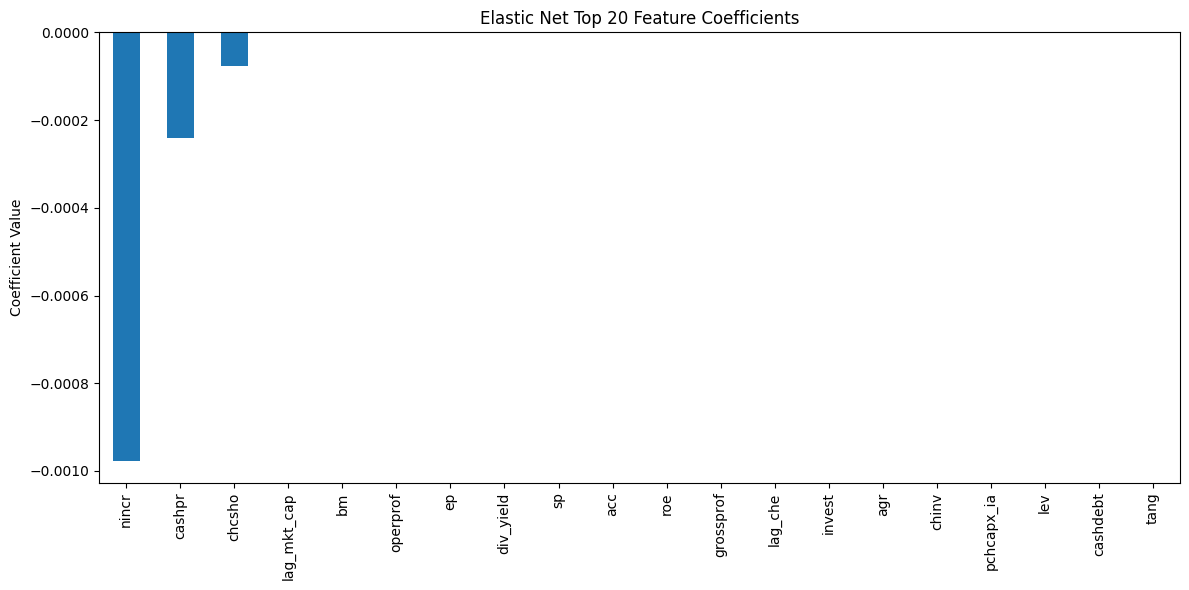

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. COMBINE TRAIN+VAL FOR TUNING
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# 2. WINSORIZE AT 1st/99th PERCENTILES
lower = X_tune.quantile(0.01)
upper = X_tune.quantile(0.99)
X_tune_w = X_tune.clip(lower=lower, upper=upper, axis=1)

# 3. STANDARDIZE FEATURES
scaler = StandardScaler()
X_tune_s = pd.DataFrame(
    scaler.fit_transform(X_tune_w),
    index=X_tune_w.index,
    columns=X_tune_w.columns
)

# 4. PREPARE TEST SET WITH SAME TRANSFORMS
X_test_w = X_test.clip(lower=lower, upper=upper, axis=1)
X_test_s = pd.DataFrame(
    scaler.transform(X_test_w),
    index=X_test_w.index,
    columns=X_test_w.columns
)

# 5. SET UP & FIT ElasticNetCV WITH TIME‐SERIES CV
tscv = TimeSeriesSplit(n_splits=5)
enet_cv = ElasticNetCV(
    l1_ratio=[0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99],
    alphas=np.logspace(-6, 2, 60),
    cv=tscv,
    max_iter=30000,
    tol=1e-4,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
enet_cv.fit(X_tune_s, y_tune)

print("Best alpha:   ", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)

# 6. PREDICT ON TEST SET
y_pred = enet_cv.predict(X_test_s)

# 7. REGRESSION METRICS
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)
print(f"MSE: {mse:.6f}, RMSE: {rmse:.6f}, R²: {r2:.4f}")

# 8. MERGE PREDICTIONS, COMPUTE TOP/BOTTOM 10% WML
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred
df_test['q90']   = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.9))
df_test['q10']   = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.1))

winners = (df_test[df_test['y_pred'] >= df_test['q90']]
           .groupby('date')['excess_next_return'].mean())
losers  = (df_test[df_test['y_pred'] <= df_test['q10']]
           .groupby('date')['excess_next_return'].mean())
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 9. PLOT CUMULATIVE WML RETURN
plt.figure(figsize=(10,6))
plt.plot(cum_wml.index, cum_wml.values, lw=2, label='Elastic Net WML')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio out-of-sample (Elastic Net)')
plt.legend()
plt.tight_layout()
plt.show()

# 10. PLOT TOP 20 COEFFICIENTS
coef_series = pd.Series(enet_cv.coef_, index=X_tune_s.columns)
coef_series = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index)

plt.figure(figsize=(12,6))
coef_series.head(20).plot(kind='bar')
plt.title('Elastic Net Top 20 Feature Coefficients')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
......................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

Best alpha:    0.26529484644318946
Best l1_ratio: 0.01
MSE: 0.059383, RMSE: 0.243687, R²: -0.0018


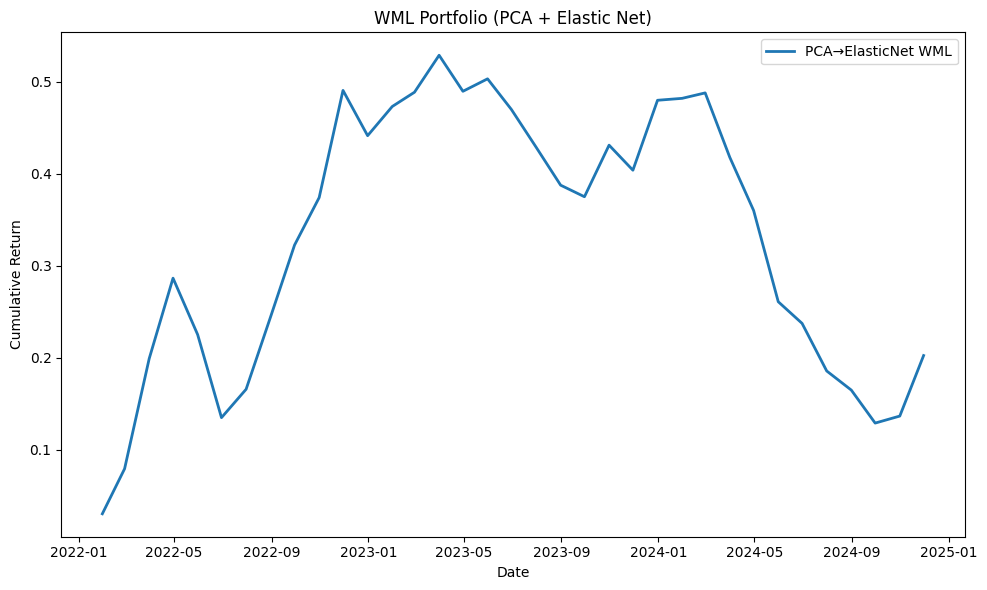

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# 1. Combine train + val for tuning
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# 2. Winsorize at 1st/99th percentiles
lower = X_tune.quantile(0.01)
upper = X_tune.quantile(0.99)
X_tune_w = X_tune.clip(lower, upper, axis=1)

# 3. Standardize features
scaler = StandardScaler()
X_tune_s = pd.DataFrame(scaler.fit_transform(X_tune_w),
                        index=X_tune_w.index,
                        columns=X_tune_w.columns)

# 4. PCA to retain 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_tune_p = pd.DataFrame(pca.fit_transform(X_tune_s),
                        index=X_tune_s.index)

# 5. Prepare test set with same transforms
X_test_w = X_test.clip(lower, upper, axis=1)
X_test_s = pd.DataFrame(scaler.transform(X_test_w),
                        index=X_test_w.index,
                        columns=X_test_w.columns)
X_test_p = pd.DataFrame(pca.transform(X_test_s), index=X_test_s.index)

# 6. ElasticNetCV with time-series CV
tscv = TimeSeriesSplit(n_splits=5)
enet_cv = ElasticNetCV(
    l1_ratio=[0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.99],
    alphas=np.logspace(-6, 2, 60),
    cv=tscv,
    max_iter=30000,
    tol=1e-4,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
enet_cv.fit(X_tune_p, y_tune)

print("Best alpha:   ", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)

# 7. Predict on test set
y_pred = enet_cv.predict(X_test_p)

# 8. Regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.6f}, RMSE: {rmse:.6f}, R²: {r2:.4f}")

# 9. Merge predictions, compute top/bottom 10% WML
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred
df_test['q90'] = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.9))
df_test['q10'] = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.1))

winners = (df_test[df_test['y_pred'] >= df_test['q90']]
           .groupby('date')['excess_next_return']
           .mean())
losers = (df_test[df_test['y_pred'] <= df_test['q10']]
          .groupby('date')['excess_next_return']
          .mean())
wml = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 10. Plot cumulative WML return
plt.figure(figsize=(10, 6))
plt.plot(cum_wml.index, cum_wml.values, lw=2, label='PCA→ElasticNet WML')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio (PCA + Elastic Net)')
plt.legend()
plt.tight_layout()
plt.show()

# 11. Project coefficients back to original features
orig_coefs = pd.Series(pca.components_.T.dot(enet_cv.coef_), index=X_tune_s.columns)
orig_coefs = orig_coefs.reindex(orig_coefs.abs().sort_values(ascending=False).index)


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Regression metrics on test set
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")

# 2. Portfolio metrics for your WML series
# Assuming `wml` is a pd.Series of periodic WML returns (e.g., monthly)
ann_factor = 12  # adjust if returns frequency differs

cum_returns = (1 + wml).cumprod()
max_drawdown = (cum_returns.cummax() - cum_returns).max()

metrics = pd.Series({
    'Annualized Return (CAGR)': (cum_returns.iloc[-1] + 1)**(ann_factor/len(wml)) - 1,
    'Annualized Volatility':    wml.std() * np.sqrt(ann_factor),
    'Sharpe Ratio':             wml.mean() / wml.std() * np.sqrt(ann_factor),
    'Max Drawdown':             max_drawdown
})

metrics_df = metrics.to_frame(name='Value')
print("\nWML Portfolio Metrics:")
display(metrics_df)

MSE:  0.059383
RMSE: 0.243687
MAE:  0.127761
R²:   -0.0018

WML Portfolio Metrics:


,Value
Annualized Return (CAGR),0.310924
Annualized Volatility,0.158614
Sharpe Ratio,0.475859
Max Drawdown,0.399715


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


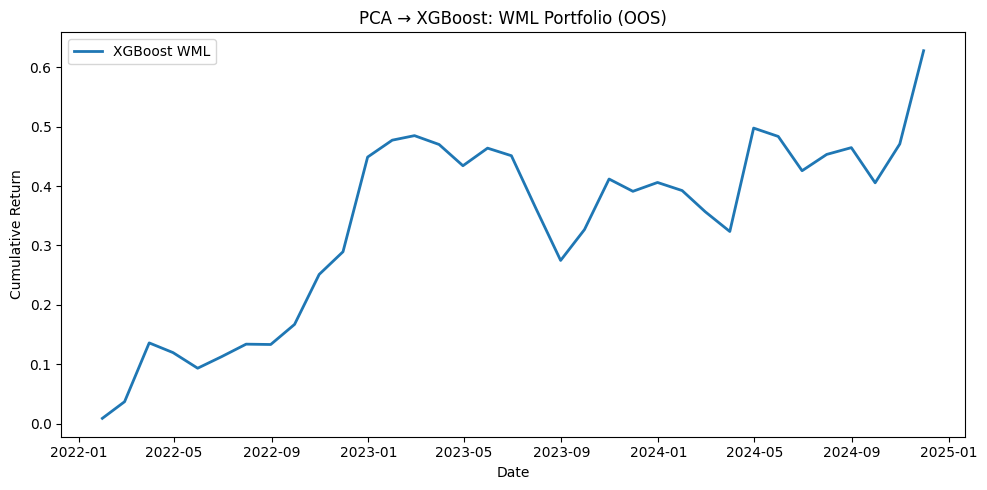

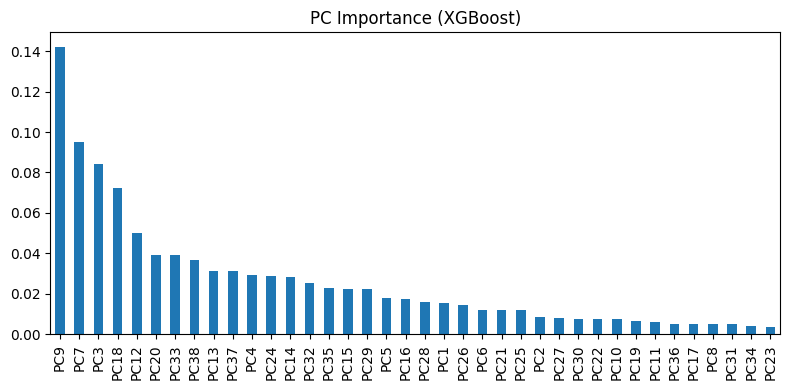

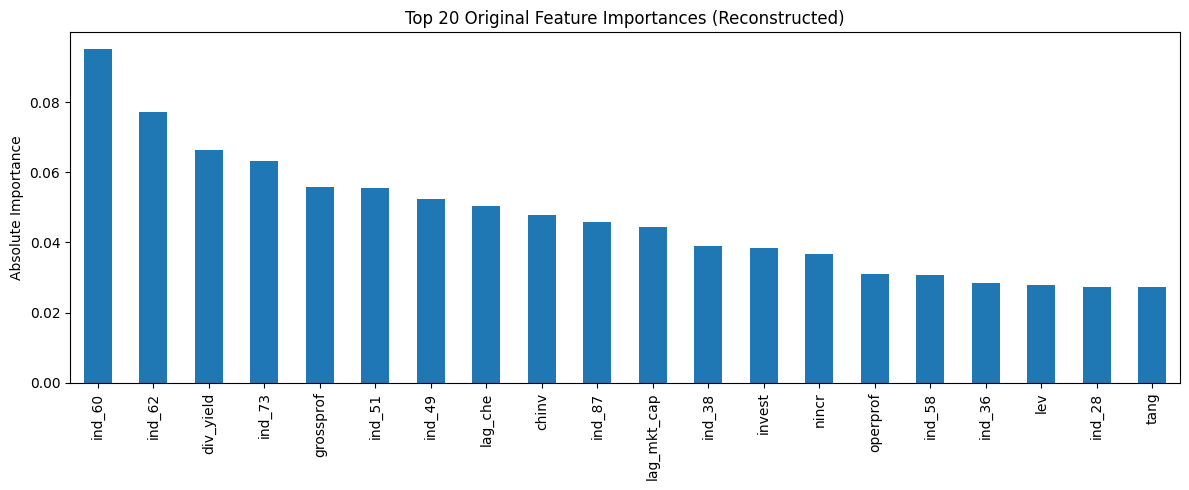

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing  import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost                 import XGBRegressor
from sklearn.metrics         import mean_squared_error

# ─── 1. PREPARE TUNING SET ─────────────────────────────────────────────────────
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# ─── 2. WINSORIZE AT 1st/99th PERCENTILES ──────────────────────────────────────
low  = X_tune.quantile(0.01)
high = X_tune.quantile(0.99)
X_tune_w = X_tune.clip(lower=low, upper=high, axis=1)

# ─── 3. STANDARDIZE ────────────────────────────────────────────────────────────
scaler = StandardScaler().fit(X_tune_w)
X_tune_s = pd.DataFrame(
    scaler.transform(X_tune_w),
    index=X_tune_w.index, columns=X_tune_w.columns
)

# ─── 4. PCA TO RETAIN 95% VARIANCE ─────────────────────────────────────────────
pca = PCA(n_components=0.95, random_state=42)
X_tune_p = pd.DataFrame(
    pca.fit_transform(X_tune_s),
    index=X_tune_s.index
)

# ─── 5. TRANSFORM TEST SET ────────────────────────────────────────────────────
X_test_w = X_test.clip(lower=low, upper=high, axis=1)
X_test_s = pd.DataFrame(
    scaler.transform(X_test_w),
    index=X_test_w.index, columns=X_test_w.columns
)
X_test_p = pd.DataFrame(
    pca.transform(X_test_s),
    index=X_test_s.index
)

# ─── 6. SET UP XGBOOST + GRID SEARCH ───────────────────────────────────────────
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 6, 9],
    'learning_rate':   [0.01, 0.05, 0.1],
    'subsample':       [0.7, 1.0],
    'colsample_bytree':[0.7, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)
xgb  = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_tune_p, y_tune)

best_xgb = grid.best_estimator_
print("Best params:", grid.best_params_)

# ─── 7. PREDICT & BUILD WML ───────────────────────────────────────────────────
y_pred = best_xgb.predict(X_test_p)

df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred

# top/bottom 10%
df_test['q90'] = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.9))
df_test['q10'] = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.1))

winners = (df_test[df_test['y_pred'] >= df_test['q90']]
           .groupby('date')['excess_next_return'].mean())
losers  = (df_test[df_test['y_pred'] <= df_test['q10']]
           .groupby('date')['excess_next_return'].mean())
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

plt.figure(figsize=(10,5))
plt.plot(cum_wml.index, cum_wml.values, lw=2, label='XGBoost WML')
plt.title('PCA → XGBoost: WML Portfolio (OOS)')
plt.xlabel('Date'); plt.ylabel('Cumulative Return')
plt.legend(); plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Regression metrics on test set
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R²:   {r2:.4f}")

# 2. Portfolio metrics for the WML series
ann_factor = 12  # if monthly returns

# Compute cumulative returns from periodic returns
cum_returns = (1 + wml).cumprod()

# CAGR
total_return = cum_returns.iloc[-1]
cagr = total_return ** (ann_factor / len(wml)) - 1

# Annualized volatility
vol_ann = wml.std() * np.sqrt(ann_factor)

# Sharpe ratio (assuming risk-free ~0)
sharpe = wml.mean() / wml.std() * np.sqrt(ann_factor)

# Max drawdown
running_max = cum_returns.cummax()
drawdown = running_max - cum_returns
max_drawdown = drawdown.max()

# Compile metrics into a DataFrame
metrics = pd.Series({
    'Annualized Return (CAGR)': cagr,
    'Annualized Volatility':    vol_ann,
    'Sharpe Ratio':             sharpe,
    'Max Drawdown':             max_drawdown
})
metrics_df = metrics.to_frame(name='Value')

print("\nWML Portfolio Metrics:")
metrics_df

MSE:  0.059366
RMSE: 0.243651
MAE:  0.127822
R²:   -0.0015

WML Portfolio Metrics:


,Value
Annualized Return (CAGR),0.181756
Annualized Volatility,0.164869
Sharpe Ratio,1.097202
Max Drawdown,0.209859


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
🔍 Best CatBoost params: {'colsample_bylevel': 0.7, 'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.01, 'subsample': 0.7}
MSE: 0.059502, RMSE: 0.243930, R²: -0.0038


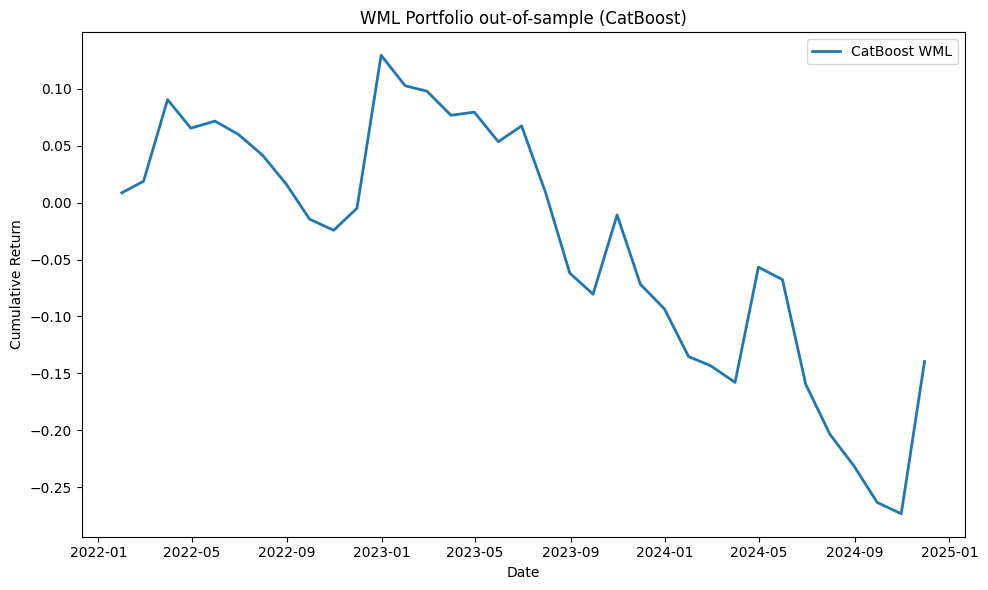

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection    import TimeSeriesSplit, GridSearchCV
from sklearn.metrics           import mean_squared_error, r2_score
from catboost                  import CatBoostRegressor

# 1. Combine train + val for tuning
X_tune = pd.concat([X_train, X_val])
y_tune = pd.concat([y_train, y_val])

# 2. Winsorize at 1st/99th percentiles
low  = X_tune.quantile(0.01)
high = X_tune.quantile(0.99)
X_tune_w = X_tune.clip(lower=low, upper=high, axis=1)

# 3. Standardize features
scaler   = StandardScaler().fit(X_tune_w)
X_tune_s = pd.DataFrame(scaler.transform(X_tune_w),
                        index=X_tune_w.index, columns=X_tune_w.columns)

# 4. Prepare test set with same transforms
X_test_w = X_test.clip(lower=low, upper=high, axis=1)
X_test_s = pd.DataFrame(scaler.transform(X_test_w),
                        index=X_test_w.index, columns=X_test_w.columns)

# 5. Set up CatBoost + GridSearchCV
param_grid = {
    'iterations':        [100, 200],
    'depth':             [4, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1],
    'l2_leaf_reg':       [1, 3, 5],
    'subsample':         [0.7, 1.0],
    'colsample_bylevel': [0.7, 1.0]
}
tscv = TimeSeriesSplit(n_splits=5)
cat = CatBoostRegressor(random_seed=42, silent=True, thread_count=-1)

grid = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_tune_s, y_tune)

best_cat = grid.best_estimator_
print("🔍 Best CatBoost params:", grid.best_params_)

# 6. Predict on test set
y_pred = best_cat.predict(X_test_s)

# 7. Regression metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
print(f"MSE: {mse:.6f}, RMSE: {rmse:.6f}, R²: {r2:.4f}")

# 8. Build WML portfolio
df_test = df_clean.loc[X_test.index].copy()
df_test['y_pred'] = y_pred
df_test['q90']   = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.9))
df_test['q10']   = df_test.groupby('date')['y_pred'].transform(lambda x: x.quantile(0.1))

winners = (df_test[df_test['y_pred'] >= df_test['q90']]
           .groupby('date')['excess_next_return']
           .mean())
losers  = (df_test[df_test['y_pred'] <= df_test['q10']]
           .groupby('date')['excess_next_return']
           .mean())
wml     = winners - losers
cum_wml = (1 + wml).cumprod() - 1

# 9. Plot cumulative WML return
plt.figure(figsize=(10, 6))
plt.plot(cum_wml.index, cum_wml.values, lw=2, label='CatBoost WML')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('WML Portfolio out-of-sample (CatBoost)')
plt.legend()
plt.tight_layout()
plt.show()